In [194]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, explained_variance_score
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt

In [195]:
rounding = 3

In [196]:
def print_feature_coefs(cols, coefs, intercept):
    idx = np.argsort(coefs)[::-1]
    zipped_list = list(zip(np.array(cols)[idx], np.round(np.array(coefs), rounding)[idx]))
    print(f"Intercept was {np.round(intercept, rounding)}")
    for item in zipped_list:
        print(f"Coef of {item[0]} was {item[1]}")

def feature_coef_dict(cols, coefs, intercept):
    dict = {}
    dict["intercept"] = np.round(intercept, rounding)
    for i in range(len(cols)):
        col = cols[i]
        dict[col] = np.round(coefs[i], rounding)
    return dict

In [197]:
df = pd.read_csv('../processed_data/processed_data.csv')
df.columns
cols = ["logVMAX12", "MSLP12", "POT12", "VGRAD0-6", "VGRAD6-12", "AL", "CP", "ONI"]
X, y = df[cols].to_numpy(), df["logVMAX36"].to_numpy()

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=int(np.floor(100*np.random.random())))
regr = LinearRegression()
params = {"fit_intercept": [True, False],
          "tol": [1e-5, 1e-6, 1e-7]}
regr_gs = GridSearchCV(regr, params, scoring="explained_variance", n_jobs=-1)
regr_gs.fit(X_train, y_train)

print("Best params:", regr_gs.best_params_)
print("Best score:", regr_gs.best_score_)

Best params: {'fit_intercept': False, 'tol': 1e-05}
Best score: 0.41368134937028006


In [199]:
regr = LinearRegression(**regr_gs.best_params_)
result = regr.fit(X_train, y_train)
# print_feature_coefs(cols, result.coef_, result.intercept_)
reg_coefs_df = pd.DataFrame({"Value": feature_coef_dict(cols, result.coef_, result.intercept_)}).T
print(reg_coefs_df.to_latex(caption="Coefficients of sklearn Linear Regression Model with basins combined", label="tab:reg_coefs"))
reg_coefs_df

\begin{table}
\caption{Coefficients of sklearn Linear Regression Model with basins combined}
\label{tab:reg_coefs}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & intercept & logVMAX12 & MSLP12 & POT12 & VGRAD0-6 & VGRAD6-12 & AL & CP & ONI \\
\midrule
Value & 0.000000 & 0.757000 & 0.001000 & 0.003000 & 0.025000 & 0.103000 & -0.023000 & -0.190000 & 0.009000 \\
\bottomrule
\end{tabular}
\end{table}



,intercept,logVMAX12,MSLP12,POT12,VGRAD0-6,VGRAD6-12,AL,CP,ONI
Value,0.0,0.757,0.001,0.003,0.025,0.103,-0.023,-0.19,0.009


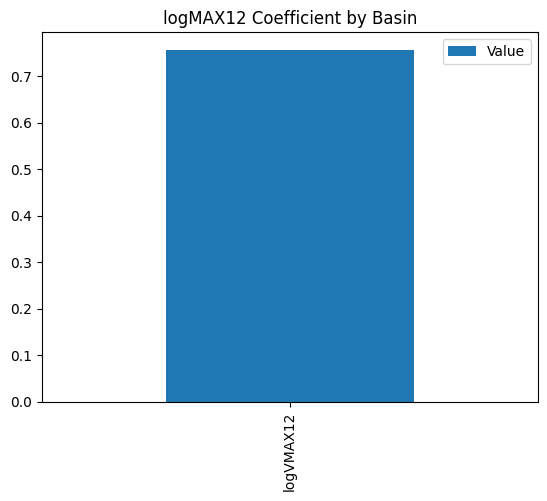

<Figure size 640x480 with 0 Axes>

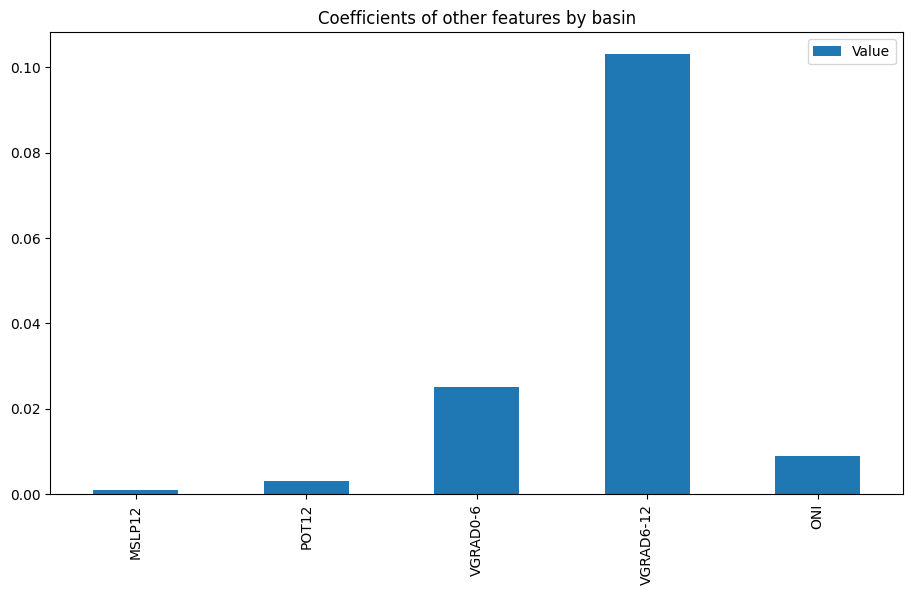

In [204]:
reg_coefs_df[['logVMAX12']].T.plot.bar()
plt.title("logMAX12 Coefficient by Basin")
plt.show()
plt.clf()
reg_coefs_df[['MSLP12', 'POT12', 'VGRAD0-6', 'VGRAD6-12', 'ONI']].T.plot.bar(figsize=(11, 6))
plt.title("Coefficients of other features by basin")
plt.show()

In [200]:
y_pred = result.predict(X_test)
out_of_sample = {"MSE": mean_squared_error(y_test, y_pred), "Explained Variance": explained_variance_score(y_test, y_pred)}
y_train_pred = result.predict(X_train)
in_sample = {"MSE": mean_squared_error(y_train, y_train_pred), "Explained Variance": explained_variance_score(y_train, y_train_pred)}
regression_results = {"In Sample": in_sample, "Out of Sample": out_of_sample}
reg_results_df = pd.DataFrame(regression_results).T
print(reg_results_df.to_latex(caption="Scoring for sklearn Linear Regression Model with basins combined", label="tab:reg_scoring"))
reg_results_df

\begin{table}
\caption{Scoring for sklearn Linear Regression Model with basins combined}
\label{tab:reg_scoring}
\begin{tabular}{lrr}
\toprule
 & MSE & Explained Variance \\
\midrule
In Sample & 0.046211 & 0.419980 \\
Out of Sample & 0.042612 & 0.427718 \\
\bottomrule
\end{tabular}
\end{table}



,MSE,Explained Variance
In Sample,0.046211,0.419980
Out of Sample,0.042612,0.427718


In [201]:
basins = ["AL", "EP", "CP"]
cols = ["logVMAX12", "MSLP12", "POT12", "VGRAD0-6", "VGRAD6-12", "ONI"]
basin_reg_coefs_dict = {}
basin_reg_scoring_dict = {}
for basin in basins:
    basin_df = df[df["Basin"] == basin]
    X, y = basin_df[cols].to_numpy(), basin_df["logVMAX36"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=int(np.floor(100*np.random.random())))
    regr = LinearRegression()
    result = regr.fit(X_train, y_train)
    basin_reg_coefs_dict[basin] = feature_coef_dict(cols, result.coef_, result.intercept_)
    y_pred = result.predict(X_test)
    basin_reg_scoring_dict[basin] = {"MSE": mean_squared_error(y_test, y_pred), "Explained Variance": explained_variance_score(y_test, y_pred)}
basin_reg_coefs_df = pd.DataFrame(basin_reg_coefs_dict).T
basin_reg_scoring_df = pd.DataFrame(basin_reg_scoring_dict).T

\begin{table}
\caption{Coefficients of sklearn Linear Regression Models with basins separated}
\label{tab:basin_reg_coefs}
\begin{tabular}{lrrrrrrr}
\toprule
 & intercept & logVMAX12 & MSLP12 & POT12 & VGRAD0-6 & VGRAD6-12 & ONI \\
\midrule
AL & 7.814000 & 0.577000 & -0.006000 & 0.002000 & 0.003000 & 0.115000 & 0.002000 \\
EP & -2.628000 & 0.793000 & 0.003000 & 0.003000 & 0.015000 & 0.110000 & -0.004000 \\
CP & -1.326000 & 0.525000 & 0.003000 & -0.002000 & 0.084000 & 0.209000 & 0.047000 \\
\bottomrule
\end{tabular}
\end{table}



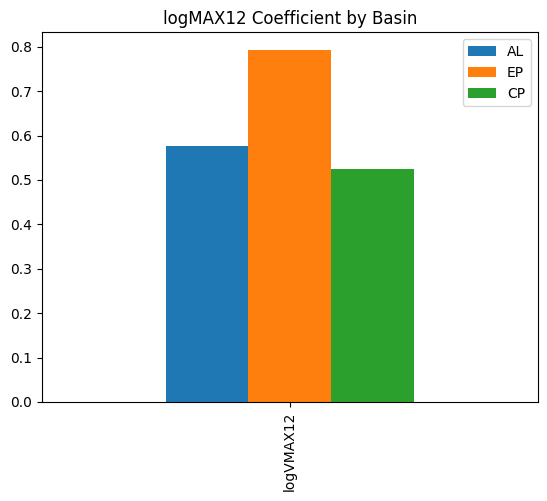

<Figure size 640x480 with 0 Axes>

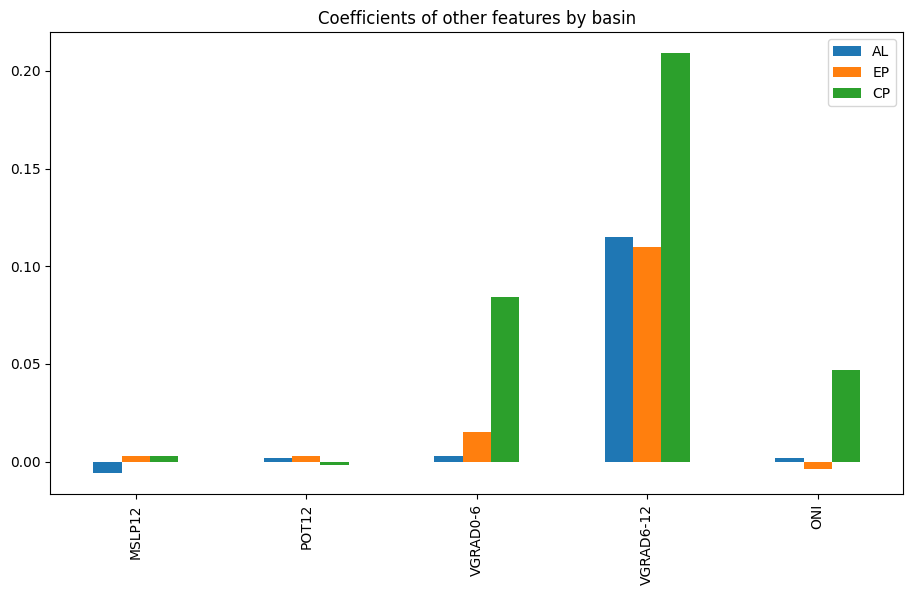

In [202]:
print(basin_reg_coefs_df.to_latex(caption="Coefficients of sklearn Linear Regression Models with basins separated", label="tab:basin_reg_coefs"))
basin_reg_coefs_df
basin_reg_coefs_df[['logVMAX12']].T.plot.bar()
plt.title("logMAX12 Coefficient by Basin")
plt.show()
plt.clf()
basin_reg_coefs_df[['MSLP12', 'POT12', 'VGRAD0-6', 'VGRAD6-12', 'ONI']].T.plot.bar(figsize=(11, 6))
plt.title("Coefficients of other features by basin")
plt.show()

In [203]:
print(basin_reg_scoring_df.to_latex(caption="Out-of-Sample Scoring for sklearn Linear Regression Model with basins separately", label="tab:basin_reg_scoring"))
basin_reg_scoring_df

\begin{table}
\caption{Out-of-Sample Scoring for sklearn Linear Regression Model with basins separately}
\label{tab:basin_reg_scoring}
\begin{tabular}{lrr}
\toprule
 & MSE & Explained Variance \\
\midrule
AL & 0.037614 & 0.518182 \\
EP & 0.043797 & 0.440680 \\
CP & 0.087833 & 0.107217 \\
\bottomrule
\end{tabular}
\end{table}



,MSE,Explained Variance
AL,0.037614,0.518182
EP,0.043797,0.440680
CP,0.087833,0.107217
